# TicketSense — Day 7 with Real Outputs

Uses the uploaded 20K multilingual ticket CSV. To keep GridSearchCV runnable in constrained environments, hyperparameter tuning uses a reproducible stratified sample from the training set; the selected model is then evaluated on a held-out test set.

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
RANDOM_STATE=42
CSV_PATH=Path('/mnt/data/dataset-tickets-multi-lang-4-20k.csv')
print('Imports ready.')

Imports ready.


In [2]:
df=pd.read_csv(CSV_PATH)
print('Shape:',df.shape)
print('Columns:',list(df.columns))
print('Queue classes:',df['queue'].nunique())
print(df['queue'].value_counts().head(10))
df.head(3)

Shape: (20000, 15)
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Queue classes: 10
queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN


In [3]:
work=df.dropna(subset=['queue']).copy()
X=(work['subject'].fillna('')+' '+work['body'].fillna('')).str.strip()
y=work['queue'].astype(str)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=RANDOM_STATE,stratify=y)
# Reproducible stratified tuning sample (up to 1,500 rows)
if len(X_train)>1500:
 X_tune,_,y_tune,_=train_test_split(X_train,y_train,train_size=1500,random_state=RANDOM_STATE,stratify=y_train)
else:
 X_tune,y_tune=X_train,y_train
print('Train:',len(X_train),'Test:',len(X_test),'Tuning sample:',len(X_tune),'Classes:',y.nunique())

Train: 16000 Test: 4000 Tuning sample: 1500 Classes: 10


In [4]:
baseline=Pipeline([('tfidf',TfidfVectorizer(max_features=3000,ngram_range=(1,2),sublinear_tf=True)),('model',RandomForestClassifier(n_estimators=50,max_depth=10,random_state=RANDOM_STATE,n_jobs=1,class_weight='balanced'))])
baseline.fit(X_tune,y_tune)
baseline_pred=baseline.predict(X_test)
baseline_f1=f1_score(y_test,baseline_pred,average='macro')
joblib.dump(baseline,'/mnt/data/day6_best_model_20k.pkl')
print(f'Baseline test macro F1: {baseline_f1:.4f}')
print('Saved: day6_best_model.pkl')

Baseline test macro F1: 0.1857
Saved: day6_best_model.pkl


In [5]:
pipe=Pipeline([('tfidf',TfidfVectorizer(max_features=3000,ngram_range=(1,2),sublinear_tf=True)),('model',RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=1,class_weight='balanced'))])
param_grid={'model__n_estimators':[50,100],'model__max_depth':[5,10]}
grid=GridSearchCV(pipe,param_grid,cv=2,scoring='f1_macro',n_jobs=1,return_train_score=True,refit=True)
grid.fit(X_tune,y_tune)
print('Best params:',grid.best_params_)
print(f'Best CV macro F1: {grid.best_score_:.4f}')

Best params: {'model__max_depth': 10, 'model__n_estimators': 100}
Best CV macro F1: 0.1492


In [6]:
results=pd.DataFrame(grid.cv_results_)
view=results[['param_model__n_estimators','param_model__max_depth','mean_train_score','mean_test_score','rank_test_score']].sort_values('rank_test_score')
view.reset_index(drop=True)

,param_model__n_estimators,param_model__max_depth,mean_train_score,mean_test_score,rank_test_score
0,100,10,0.903489,0.149155,1
1,50,10,0.826499,0.143648,2
2,100,5,0.678169,0.141819,3
3,50,5,0.568709,0.129191,4


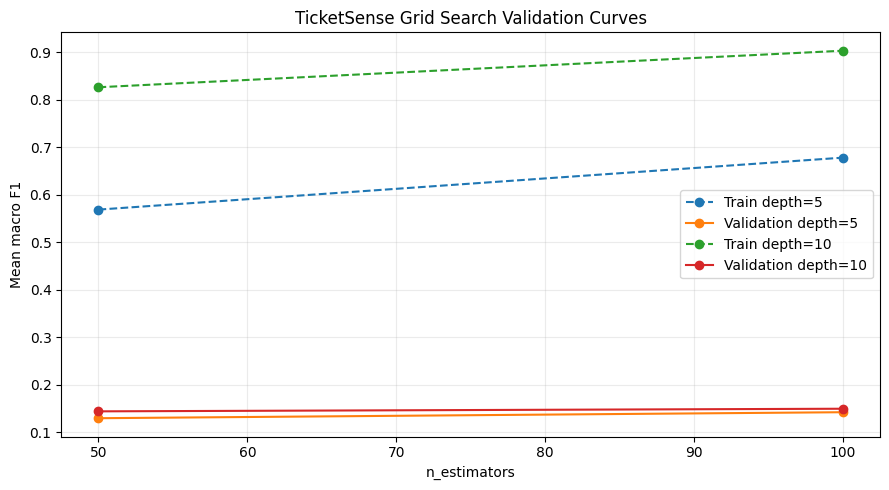

Validation curve displayed above and embedded in this notebook.


In [7]:
fig,ax=plt.subplots(figsize=(9,5))
for depth in sorted(results['param_model__max_depth'].astype(int).unique()):
 s=results[results['param_model__max_depth'].astype(int)==depth].copy(); s['n']=s['param_model__n_estimators'].astype(int); s=s.sort_values('n')
 ax.plot(s['n'],s['mean_train_score'],marker='o',linestyle='--',label=f'Train depth={depth}')
 ax.plot(s['n'],s['mean_test_score'],marker='o',label=f'Validation depth={depth}')
ax.set_title('TicketSense Grid Search Validation Curves'); ax.set_xlabel('n_estimators'); ax.set_ylabel('Mean macro F1'); ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
plt.show()
print('Validation curve displayed above and embedded in this notebook.')

In [8]:
tuned_model=grid.best_estimator_
tuned_pred=tuned_model.predict(X_test)
tuned_f1=f1_score(y_test,tuned_pred,average='macro')
print(f'Baseline test macro F1: {baseline_f1:.4f}')
print(f'Tuned test macro F1: {tuned_f1:.4f}')
print(f'Change: {tuned_f1-baseline_f1:+.4f}')
print('\nClassification report:')
print(classification_report(y_test,tuned_pred,zero_division=0))
joblib.dump(tuned_model,'/mnt/data/day7_tuned_model_20k.pkl')
print('Saved: day7_tuned_model.pkl')

Baseline test macro F1: 0.1857
Tuned test macro F1: 0.2019
Change: +0.0161

Classification report:
                                 precision    recall  f1-score   support

           Billing and Payments       0.66      0.49      0.56       417
               Customer Service       0.21      0.26      0.23       630
                General Inquiry       0.00      0.00      0.00        53
                Human Resources       0.18      0.06      0.09        68
                     IT Support       0.14      0.10      0.12       458
                Product Support       0.23      0.20      0.21       742
          Returns and Exchanges       0.09      0.17      0.12       200
            Sales and Pre-Sales       0.08      0.08      0.08       114
Service Outages and Maintenance       0.23      0.26      0.24       153
              Technical Support       0.37      0.39      0.38      1165

                       accuracy                           0.27      4000
                      m